## Lab 2 CNN

In [ ]:
import numpy as np
import pandas as pd
from torchvision.datasets import MNIST
from torchvision.transforms import ToTensor #para poder tratar los datos como data set tabular
from collections import Counter

#descarga
train_data = MNIST(root='./datos', train=True, download=True, transform=ToTensor())
test_data = MNIST(root='./datos', train=False, download=True, transform=ToTensor())

In [13]:
from collections import Counter
import matplotlib.pyplot as plt

### Exploracion y preparacion de datos 

=== EXPLORACION Y PREPARACION DATASET ===
 - Observaciones en entrenamiento: 60000
 - Observaciones en prueba: 10000
	Total: 70000

Total de clases: 10
	['0 - zero', '1 - one', '2 - two', '3 - three', '4 - four', '5 - five', '6 - six', '7 - seven', '8 - eight', '9 - nine']

Distribucion clases:
  Digito 0: 5923 imagenes (9.87%, diferencia del 1.28% al balance)
  Digito 1: 6742 imagenes (11.24%, diferencia del 12.37% al balance)
  Digito 2: 5958 imagenes (9.93%, diferencia del 0.70% al balance)
  Digito 3: 6131 imagenes (10.22%, diferencia del 2.18% al balance)
  Digito 4: 5842 imagenes (9.74%, diferencia del 2.63% al balance)
  Digito 5: 5421 imagenes (9.04%, diferencia del 9.65% al balance)
  Digito 6: 5918 imagenes (9.86%, diferencia del 1.37% al balance)
  Digito 7: 6265 imagenes (10.44%, diferencia del 4.42% al balance)
  Digito 8: 5851 imagenes (9.75%, diferencia del 2.48% al balance)
  Digito 9: 5949 imagenes (9.92%, diferencia del 0.85% al balance)


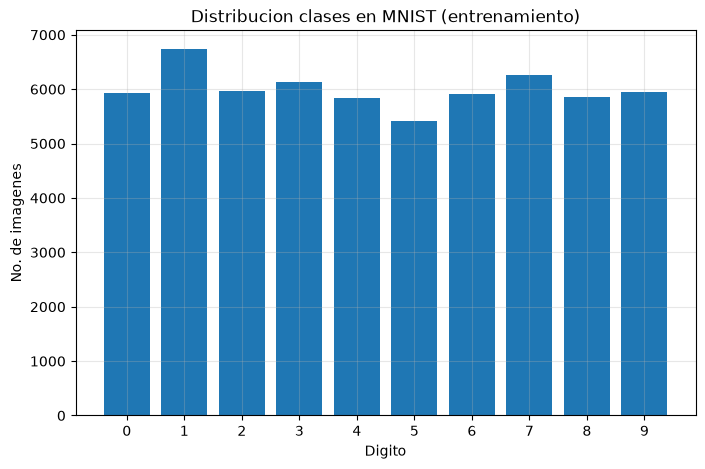

In [16]:
print("=== EXPLORACION Y PREPARACION DATASET ===")
obs_training = len(train_data)
obs_test = len(test_data)
print(f" - Observaciones en entrenamiento: {obs_training}")
print(f" - Observaciones en prueba: {obs_test}")
print(f"\tTotal: {obs_training + obs_test}")
print(f"\nTotal de clases: {len(train_data.classes)}")
print(f"\t{train_data.classes}")
#balanceo clases
train_labels = [label for _, label in train_data]
counter = Counter(train_labels)
total_train = len(train_data)

print(f"\nDistribucion clases:")
for digito in range(10):
    percentage = (counter[digito]/total_train)*100
    expected = total_train/len(train_data.classes)
    diff = abs(counter[digito]- expected)/expected*100

    print(f"  Digito {digito}: {counter[digito]} imagenes ({percentage:.2f}%, diferencia del {diff:.2f}% al balance)")

#grafica
plt.figure(figsize=(8, 5))
plt.bar(counter.keys(), counter.values())
plt.xlabel('Digito')
plt.ylabel('No. de imagenes')
plt.title('Distribucion clases en MNIST (entrenamiento)')
plt.xticks(range(10))
plt.grid(True, alpha=0.3)
plt.show()



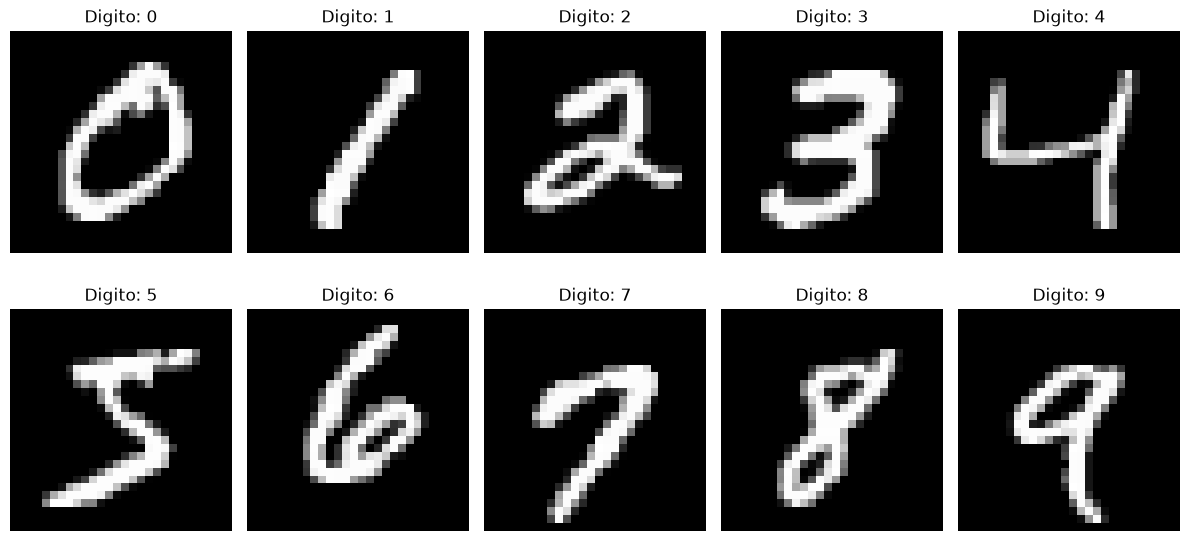

In [18]:
fig, axes = plt.subplots(2, 5, figsize=(12, 6))
for i, ax in enumerate(axes.flat):
    #ejmplos imagnes digitos
    for img, label in train_data:
        if label == i:
            ax.imshow(img.squeeze(), cmap='gray')
            ax.set_title(f'Digito: {i}')
            ax.axis('off')
            break
plt.tight_layout()
plt.show()